# Rékolte – Notebook 2 v3 (revised): Pre-Harvest Model Training (39 features)

**Project:** Predicting Sugarcane Yield in Mauritius Using Satellite Imagery
**Student:** Yashvin Booputh (M01006629), BSc Computer Science, Middlesex University Mauritius

### What's new in v3 vs v2 (35 features)
| Addition | Details |
|----------|---------|
| `cyclone_max_wind` | Max sustained wind (km/h) within **200 km** of Mauritius Jan-May (IBTRACS v04r00) |
| `enso_oni_djf` | ENSO ONI **anomaly** Dec(Y-1)-Jan-Feb(Y) — NOAA CPC (fixed from earlier SST parse error) |
| `ndvi_growth` | ndvi_may - ndvi_oct — net vegetative gain across pre-harvest window |
| `ndvi_jan_may_mean` | Mean NDVI Jan-May — growth phase immediately before harvest |

**Dropped vs first v3 attempt:** ndvi_peak_oct_may, ndvi_jan_may_slope (redundant for tree models)
**No RF tuning** — XGBoost only (RF tuning gave negligible return)

**Input:**  `model_v3/pre_harvest_features.csv` (shared — no re-extraction needed)
**Output:** `model_v3/rf_model_v3.joblib`, `model_v3/xgb_model_v3.ubj`

## Cell 1 - Install Packages

In [1]:
!pip install scikit-learn xgboost shap joblib scipy --quiet
print('Packages ready.')

Packages ready.


## Cell 2 - Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
import math
import json
import requests
import joblib

from io import StringIO
from scipy.stats import uniform, randint

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneGroupOut, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb
from xgboost import XGBRegressor

import shap

warnings.filterwarnings('ignore')
np.random.seed(42)
print('Imports OK.')
print(f'XGBoost version: {xgb.__version__}')

Imports OK.
XGBoost version: 3.2.0


## Cell 3 - Mount Google Drive & Load Data

In [3]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_BASE     = '/content/drive/MyDrive/CST3990 - Final Year Project'
V3_DIR         = f'{DRIVE_BASE}/model_v3'   # all v3 files in one place
DATA_DIR       = f'{DRIVE_BASE}/data'

PREHARVEST_CSV = f'{V3_DIR}/pre_harvest_features.csv'
HARVEST_CSV    = f'{DATA_DIR}/season_end_data.csv'

RF_MODEL_OUT   = f'{V3_DIR}/rf_model_v3.joblib'
XGB_MODEL_OUT  = f'{V3_DIR}/xgb_model_v3.joblib'
PREDS_OUT      = f'{V3_DIR}/loso_predictions_v3.csv'

os.makedirs(V3_DIR, exist_ok=True)

df_feat    = pd.read_csv(PREHARVEST_CSV)
df_harvest = pd.read_csv(HARVEST_CSV)

print(f'Pre-harvest features: {df_feat.shape[0]} rows x {df_feat.shape[1]} cols')
print(f'Season end data:      {df_harvest.shape[0]} rows x {df_harvest.shape[1]} cols')
print(f'\nPre-harvest seasons: {sorted(df_feat["season"].unique().tolist())}')

Mounted at /content/drive
Pre-harvest features: 85 rows x 35 cols
Season end data:      90 rows x 11 cols

Pre-harvest seasons: [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


## Cell 4 - External Climate Indicators

**Fix vs first v3 attempt:**
- Cyclone radius tightened from 300 km → **200 km** (300 km captured too many weak/distant storms,
  reducing discriminative power — 11/17 years were non-zero)
- ENSO parsing fixed: previous run read the raw SST column (~27°C) instead of the ONI **anomaly**
  column. Now reads `parts[-1]` (last column = ANOM). A runtime validation check catches any
  future parse errors.

**ENSO DJF interpretation:**
- ONI >= +0.5 = El Niño (warmer SST → drought tendency for Mauritius)
- ONI <= -0.5 = La Niña (cooler SST → above-normal rainfall, waterlogging risk)
- |ONI| < 0.5 = Neutral

In [4]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = (math.sin(dlat/2)**2 +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon/2)**2)
    return R * 2 * math.asin(math.sqrt(max(0.0, min(1.0, a))))

MAURITIUS_LAT = -20.2
MAURITIUS_LON =  57.5
RADIUS_KM     = 200.0   # tightened from 300 km

# ── IBTRACS South Indian Ocean ────────────────────────────────────────────────
print('Downloading IBTRACS (South Indian Ocean)... (~30-60 s)')
IBTRACS_URL = (
    'https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs'
    '/v04r00/access/csv/ibtracs.SI.list.v04r00.csv'
)
resp = requests.get(IBTRACS_URL, timeout=180)
resp.raise_for_status()

# Row 0 = column headers, Row 1 = units row (skip it)
df_ib = pd.read_csv(StringIO(resp.text), skiprows=[1], low_memory=False, na_values=[' ', ''])
df_ib['ISO_TIME'] = pd.to_datetime(df_ib['ISO_TIME'], errors='coerce')
df_ib = df_ib.dropna(subset=['ISO_TIME'])
df_ib['_year']  = df_ib['ISO_TIME'].dt.year
df_ib['_month'] = df_ib['ISO_TIME'].dt.month

df_ib = df_ib[df_ib['_month'].between(1, 5) & df_ib['_year'].between(2009, 2025)].copy()
df_ib['_lat'] = pd.to_numeric(df_ib['LAT'],      errors='coerce')
df_ib['_lon'] = pd.to_numeric(df_ib['LON'],      errors='coerce')
df_ib['_wnd'] = pd.to_numeric(df_ib['WMO_WIND'], errors='coerce')   # knots
df_ib = df_ib.dropna(subset=['_lat', '_lon', '_wnd'])

df_ib['_dist_km'] = df_ib.apply(
    lambda r: haversine_km(MAURITIUS_LAT, MAURITIUS_LON, r['_lat'], r['_lon']), axis=1
)
df_near = df_ib[df_ib['_dist_km'] <= RADIUS_KM].copy()
df_near['_wind_kmh'] = df_near['_wnd'] * 1.852

cyclone_lookup = {y: 0.0 for y in range(2009, 2026)}
for year, grp in df_near.groupby('_year'):
    if year in cyclone_lookup:
        cyclone_lookup[year] = round(float(grp['_wind_kmh'].max()), 1)

n_impact = sum(1 for v in cyclone_lookup.values() if v > 0)
print(f'Done. {len(df_near)} obs within 200 km. {n_impact}/17 years have cyclone impact.\n')
print('Cyclone max wind (km/h) within 200 km of Mauritius, Jan-May:')
for y in sorted(cyclone_lookup):
    v = cyclone_lookup[y]
    flag = f'  <-- {v:.0f} km/h' if v > 0 else ''
    print(f'  {y}: {v:5.1f}{flag}')

# ── ENSO ONI DJF (anomaly) ────────────────────────────────────────────────────
# Fix: NOAA CPC oni.ascii.txt has columns SEAS YR TOTAL CLIM ANOM
# Previous run mistakenly read parts[2] = TOTAL (raw SST ~27C).
# Now reading parts[-1] = ANOM (anomaly, expected range -3 to +3).
print('\nDownloading ONI data from NOAA CPC...')
ONI_URL = 'https://www.cpc.ncep.noaa.gov/data/indices/oni.ascii.txt'
resp_oni = requests.get(ONI_URL, timeout=30)
resp_oni.raise_for_status()

oni_rows = []
for line in resp_oni.text.strip().split('\n'):
    parts = line.split()
    if len(parts) >= 3 and parts[0] not in ('SEAS', 'seas'):
        try:
            oni_rows.append({
                'season': parts[0],
                'year':   int(parts[1]),
                'anom':   float(parts[-1])   # last column = ANOM regardless of format
            })
        except ValueError:
            pass

df_oni = pd.DataFrame(oni_rows)

# Runtime validation — ONI anomalies must be in a plausible range
anom_max = df_oni['anom'].max()
anom_min = df_oni['anom'].min()
if anom_max > 5 or anom_min < -5:
    raise ValueError(
        f'ONI values out of expected range (got {anom_min:.2f} to {anom_max:.2f}). '
        'Still reading SST column — check NOAA file format and column index.'
    )
print(f'ONI range check passed: {anom_min:.2f} to {anom_max:.2f}  (expected -3 to +3)')

# DJF for prediction year Y = Dec(Y-1)+Jan(Y)+Feb(Y); NOAA labels row year=Y
df_djf = df_oni[df_oni['season'] == 'DJF'].set_index('year')

enso_lookup = {}
for pred_year in range(2009, 2026):
    if pred_year in df_djf.index:
        enso_lookup[pred_year] = round(float(df_djf.loc[pred_year, 'anom']), 2)
    else:
        enso_lookup[pred_year] = 0.0
        print(f'  WARNING: ONI DJF not found for {pred_year}, using 0.0')

print('\nENSO DJF ONI anomaly (Dec(Y-1)-Jan(Y)-Feb(Y)):')
for y in sorted(enso_lookup):
    v = enso_lookup[y]
    phase = 'El Nino ' if v >= 0.5 else ('La Nina ' if v <= -0.5 else 'Neutral ')
    print(f'  {y}: {v:+.2f}  ({phase})')

print('\nExternal climate indicators ready.')

Done. 20 obs within 200 km. 6/17 years have cyclone impact.

Cyclone max wind (km/h) within 200 km of Mauritius, Jan-May:
  2009:   0.0
  2010:   0.0
  2011:   0.0
  2012:   0.0
  2013:  55.6  <-- 56 km/h
  2014: 101.9  <-- 102 km/h
  2015:   0.0
  2016:   0.0
  2017:  70.4  <-- 70 km/h
  2018: 120.4  <-- 120 km/h
  2019:   0.0
  2020:  70.4  <-- 70 km/h
  2021:  40.7  <-- 41 km/h
  2022:   0.0
  2023:   0.0
  2024:   0.0
  2025:   0.0

ONI range check passed: -2.03 to 2.75  (expected -3 to +3)

ENSO DJF ONI anomaly (Dec(Y-1)-Jan(Y)-Feb(Y)):
  2009: -0.85  (La Nina )
  2010: +1.50  (El Nino )
  2011: -1.31  (La Nina )
  2012: -0.72  (La Nina )
  2013: -0.29  (Neutral )
  2014: -0.28  (Neutral )
  2015: +0.69  (El Nino )
  2016: +2.63  (El Nino )
  2017: -0.19  (Neutral )
  2018: -0.77  (La Nina )
  2019: +0.89  (El Nino )
  2020: +0.64  (El Nino )
  2021: -0.91  (La Nina )
  2022: -0.82  (La Nina )
  2023: -0.54  (La Nina )
  2024: +1.92  (El Nino )
  2025: -0.45  (Neutral )

External 

## Cell 5 - Compute surface_prev & Merge Datasets

`surface_prev` = harvested area (ha) from season Y-1 for the same region.

In [5]:
df_surf = df_harvest[['season', 'region', 'surface_harvested']].copy()
df_surf['season'] = df_surf['season'] + 1
df_surf = df_surf.rename(columns={'surface_harvested': 'surface_prev'})

df_target = df_harvest[['season', 'region', 'tch', 'surface_harvested']].copy()

df = df_feat.merge(df_target, on=['season', 'region'], how='inner')
df = df.merge(df_surf,   on=['season', 'region'], how='left')
df = df[df['season'] >= 2009].reset_index(drop=True)

print(f'Merged dataset: {df.shape[0]} rows x {df.shape[1]} cols')
print(f'Seasons: {sorted(df["season"].unique().tolist())}')
print(f'Regions: {sorted(df["region"].unique().tolist())}')
print(f'\nMissing surface_prev: {df["surface_prev"].isnull().sum()}')
print(f'Missing tch:          {df["tch"].isnull().sum()}')
print(f'\nTCH summary:')
print(df['tch'].describe().round(2).to_string())

Merged dataset: 85 rows x 38 cols
Seasons: [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Regions: ['CENTRE', 'EST', 'NORD', 'OUEST', 'SUD']

Missing surface_prev: 0
Missing tch:          0

TCH summary:
count    85.00
mean     74.59
std      10.91
min      40.60
25%      67.70
50%      75.70
75%      82.00
max      99.90


## Cell 6 - Imputation, Feature Engineering & Matrix Construction (39 features)

### NDVI derived features kept (2 of the original 4)
| Feature | Formula | Rationale |
|---------|---------|-----------|
| `ndvi_growth` | ndvi_may - ndvi_oct | Net vegetative gain across full window |
| `ndvi_jan_may_mean` | mean(ndvi_jan...ndvi_may) | Average greenness in growth phase |

Dropped: `ndvi_peak_oct_may` (correlated with ndvi_may), `ndvi_jan_may_slope`
(redundant — tree models can infer trends from monthly snapshots).

In [6]:
MONTHLY_NDVI_COLS = ['ndvi_oct', 'ndvi_nov', 'ndvi_dec',
                     'ndvi_jan', 'ndvi_feb', 'ndvi_mar', 'ndvi_apr', 'ndvi_may']
JAN_MAY_COLS      = ['ndvi_jan', 'ndvi_feb', 'ndvi_mar', 'ndvi_apr', 'ndvi_may']

# ── Imputation (two-tier, same as v2) ─────────────────────────────────────────
zero_mask = df[MONTHLY_NDVI_COLS].isnull().all(axis=1)
if zero_mask.sum() > 0:
    print(f'WARNING: fully-null NDVI rows: {sorted(df.loc[zero_mask,"season"].unique().tolist())}')

print('--- Tier-1: row-mean ---')
row_means = df[MONTHLY_NDVI_COLS].mean(axis=1)
for col in MONTHLY_NDVI_COLS:
    mask = df[col].isnull()
    df.loc[mask, col] = row_means[mask]
    if mask.sum() > 0: print(f'  {mask.sum()} imputed in {col}')

print('--- Tier-2: column-mean fallback ---')
col_means = df[MONTHLY_NDVI_COLS].mean()
for col in MONTHLY_NDVI_COLS:
    mask = df[col].isnull()
    if mask.sum() > 0:
        df.loc[mask, col] = col_means[col]
        print(f'  {mask.sum()} imputed in {col}')

LAG_NDVI_COLS = ['ndvi_lag_mean', 'ndvi_lag_max', 'ndvi_lag_std', 'ndvi_lag_cumulative']
CLIMATE_COLS  = (
    ['rainfall_lag_total', 'temp_lag_mean'] +
    [f'rainfall_{m}' for m in ['oct','nov','dec','jan','feb','mar','apr','may']] +
    [f'temp_{m}'     for m in ['oct','nov','dec','jan','feb','mar','apr','may']]
)
for col in LAG_NDVI_COLS + CLIMATE_COLS:
    mask = df[col].isnull()
    if mask.sum() > 0: df.loc[mask, col] = df[col].mean()

df['surface_prev'] = df['surface_prev'].fillna(df['surface_prev'].mean())

# ── NDVI derived features (2 kept) ───────────────────────────────────────────
df['ndvi_growth']       = df['ndvi_may'] - df['ndvi_oct']
df['ndvi_jan_may_mean'] = df[JAN_MAY_COLS].mean(axis=1)

# ── External indicators ───────────────────────────────────────────────────────
df['cyclone_max_wind'] = df['season'].map(cyclone_lookup).fillna(0.0)
df['enso_oni_djf']     = df['season'].map(enso_lookup).fillna(0.0)

# ── Region one-hot (CENTRE = baseline) ───────────────────────────────────────
region_dummies = pd.get_dummies(df['region'], prefix='region', drop_first=False)
region_dummies = region_dummies.drop(columns=['region_CENTRE'], errors='ignore')
df = pd.concat([df, region_dummies], axis=1)

# ── Feature list (39) ─────────────────────────────────────────────────────────
FEATURE_COLS = (
    LAG_NDVI_COLS +
    ['rainfall_lag_total', 'temp_lag_mean'] +
    MONTHLY_NDVI_COLS +
    [f'rainfall_{m}' for m in ['oct','nov','dec','jan','feb','mar','apr','may']] +
    [f'temp_{m}'     for m in ['oct','nov','dec','jan','feb','mar','apr','may']] +
    list(region_dummies.columns) +
    ['surface_prev'] +
    ['ndvi_growth', 'ndvi_jan_may_mean'] +
    ['cyclone_max_wind', 'enso_oni_djf']
)

TARGET_COL = 'tch'
X      = df[FEATURE_COLS].values.astype(float)
y      = df[TARGET_COL].values.astype(float)
groups = df['season'].values

print(f'\nFeature matrix X: {X.shape}  (should be 85 x 39)')
print(f'Any NaN in X:     {np.isnan(X).any()}  <- must be False')
print(f'Any NaN in y:     {np.isnan(y).any()}')
print(f'\nFeature columns ({len(FEATURE_COLS)}):')
for i, c in enumerate(FEATURE_COLS):
    print(f'  {i+1:2d}. {c}')

cyc_years = [yr for yr in sorted(cyclone_lookup) if cyclone_lookup[yr] > 0]
print(f'\nCyclone-impacted years (200 km, >0 km/h): {cyc_years}  ({len(cyc_years)}/17)')
enso_ext  = [(yr,v) for yr,v in sorted(enso_lookup.items()) if abs(v) >= 0.5]
print(f'ENSO extremes (|ONI|>=0.5): {enso_ext}')

--- Tier-1: row-mean ---
--- Tier-2: column-mean fallback ---

Feature matrix X: (85, 39)  (should be 85 x 39)
Any NaN in X:     False  <- must be False
Any NaN in y:     False

Feature columns (39):
   1. ndvi_lag_mean
   2. ndvi_lag_max
   3. ndvi_lag_std
   4. ndvi_lag_cumulative
   5. rainfall_lag_total
   6. temp_lag_mean
   7. ndvi_oct
   8. ndvi_nov
   9. ndvi_dec
  10. ndvi_jan
  11. ndvi_feb
  12. ndvi_mar
  13. ndvi_apr
  14. ndvi_may
  15. rainfall_oct
  16. rainfall_nov
  17. rainfall_dec
  18. rainfall_jan
  19. rainfall_feb
  20. rainfall_mar
  21. rainfall_apr
  22. rainfall_may
  23. temp_oct
  24. temp_nov
  25. temp_dec
  26. temp_jan
  27. temp_feb
  28. temp_mar
  29. temp_apr
  30. temp_may
  31. region_EST
  32. region_NORD
  33. region_OUEST
  34. region_SUD
  35. surface_prev
  36. ndvi_growth
  37. ndvi_jan_may_mean
  38. cyclone_max_wind
  39. enso_oni_djf

Cyclone-impacted years (200 km, >0 km/h): [2013, 2014, 2017, 2018, 2020, 2021]  (6/17)
ENSO extremes (|O

## Cell 7 - Exploratory Analysis

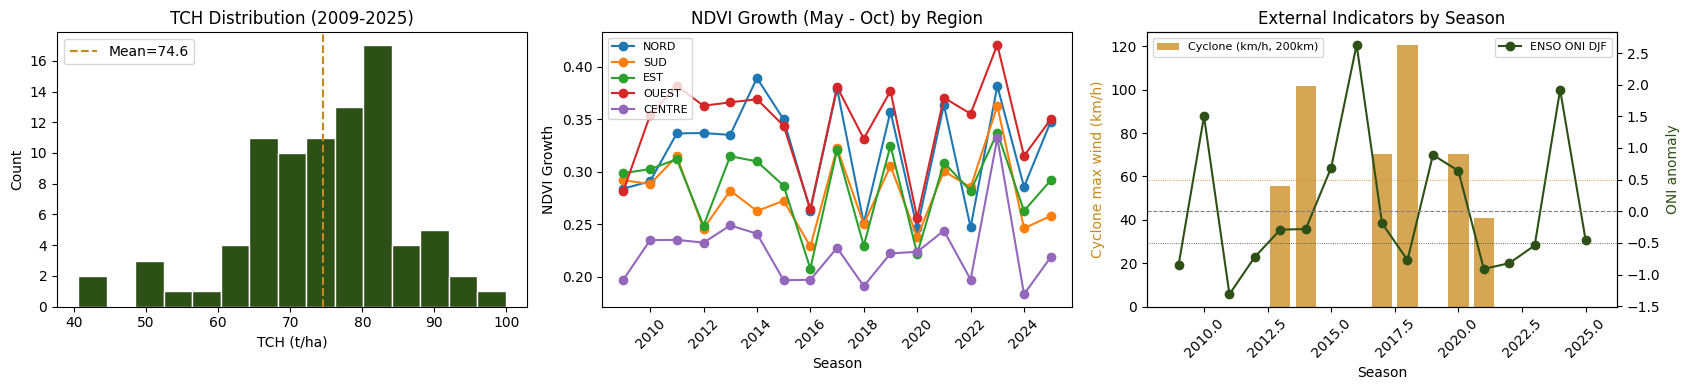

EDA plot saved.


In [7]:
seasons_unique = sorted(df['season'].unique())

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].hist(y, bins=15, color='#2d5016', edgecolor='white')
axes[0].set_title('TCH Distribution (2009-2025)')
axes[0].set_xlabel('TCH (t/ha)')
axes[0].set_ylabel('Count')
axes[0].axvline(np.mean(y), color='#C8891A', linestyle='--', label=f'Mean={np.mean(y):.1f}')
axes[0].legend()

for region in ['NORD', 'SUD', 'EST', 'OUEST', 'CENTRE']:
    sub = df[df['region'] == region].sort_values('season')
    axes[1].plot(sub['season'], sub['ndvi_growth'], marker='o', label=region, linewidth=1.5)
axes[1].set_title('NDVI Growth (May - Oct) by Region')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('NDVI Growth')
axes[1].legend(fontsize=8)
axes[1].tick_params(axis='x', rotation=45)

ax2b = axes[2].twinx()
cyc_vals  = [cyclone_lookup.get(yr, 0) for yr in seasons_unique]
enso_vals = [enso_lookup.get(yr, 0)   for yr in seasons_unique]
axes[2].bar(seasons_unique, cyc_vals, color='#C8891A', alpha=0.75, label='Cyclone (km/h, 200km)')
ax2b.plot(seasons_unique, enso_vals, color='#2d5016', marker='o', linewidth=1.5, label='ENSO ONI DJF')
ax2b.axhline(0,    color='grey',    linewidth=0.8, linestyle='--')
ax2b.axhline(0.5,  color='#C8891A', linewidth=0.6, linestyle=':')
ax2b.axhline(-0.5, color='#2d5016', linewidth=0.6, linestyle=':')
axes[2].set_title('External Indicators by Season')
axes[2].set_xlabel('Season')
axes[2].set_ylabel('Cyclone max wind (km/h)', color='#C8891A')
ax2b.set_ylabel('ONI anomaly', color='#2d5016')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend(loc='upper left', fontsize=8)
ax2b.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig(f'{V3_DIR}/eda_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA plot saved.')

## Cell 8 - LOSO CV Helper

In [8]:
def run_loso(model, X, y, groups, feature_names):
    logo    = LeaveOneGroupOut()
    all_preds, fold_rmse, fold_mae, fold_r2 = [], [], [], []

    for train_idx, test_idx in logo.split(X, y, groups):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        season_out      = groups[test_idx][0]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        fold_rmse.append(float(np.sqrt(mean_squared_error(y_test, y_pred))))
        fold_mae.append(float(mean_absolute_error(y_test, y_pred)))
        fold_r2.append(float(r2_score(y_test, y_pred)))

        for actual, predicted in zip(y_test, y_pred):
            all_preds.append({'season': season_out, 'actual': actual, 'predicted': predicted})

    df_preds = pd.DataFrame(all_preds)
    return {
        'loso_rmse':   float(np.sqrt(mean_squared_error(df_preds['actual'], df_preds['predicted']))),
        'loso_mae':    float(mean_absolute_error(df_preds['actual'], df_preds['predicted'])),
        'loso_r2':     float(r2_score(df_preds['actual'], df_preds['predicted'])),
        'fold_rmse':   fold_rmse,
        'fold_mae':    fold_mae,
        'fold_r2':     fold_r2,
        'predictions': df_preds
    }

seasons_list = sorted(df['season'].unique())
print(f'LOSO helper defined.  Folds: {len(seasons_list)}')

LOSO helper defined.  Folds: 17


## Cell 9 - Baseline LOSO: Random Forest (39 features)

In [9]:
rf_base = RandomForestRegressor(
    n_estimators=500, max_depth=None, min_samples_leaf=2,
    max_features='sqrt', random_state=42, n_jobs=-1
)
print('Running baseline LOSO CV for Random Forest (39 features)...')
rf_results = run_loso(rf_base, X, y, groups, FEATURE_COLS)

print(f'\nRandom Forest v3 Baseline LOSO')
print(f'  RMSE: {rf_results["loso_rmse"]:.4f}')
print(f'  MAE:  {rf_results["loso_mae"]:.4f}')
print(f'  R2:   {rf_results["loso_r2"]:.4f}')
print(f'\nPer-season R2:')
for s, r2 in zip(seasons_list, rf_results['fold_r2']):
    bar = '#' * max(0, int((r2 + 0.5) * 20))
    print(f'  {s}: {r2:+.3f}  {bar}')

Running baseline LOSO CV for Random Forest (39 features)...

Random Forest v3 Baseline LOSO
  RMSE: 8.2755
  MAE:  6.6387
  R2:   0.4174

Per-season R2:
  2009: -0.670  
  2010: +0.094  ###########
  2011: -0.032  #########
  2012: -12.081  
  2013: +0.553  #####################
  2014: -3.022  
  2015: +0.078  ###########
  2016: +0.157  #############
  2017: +0.849  ##########################
  2018: +0.377  #################
  2019: +0.735  ########################
  2020: -1.614  
  2021: -0.287  ####
  2022: -0.505  
  2023: +0.521  ####################
  2024: +0.365  #################
  2025: +0.539  ####################


## Cell 10 - Baseline LOSO: XGBoost (39 features)

In [10]:
xgb_base = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=2,
    gamma=0.1, reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, verbosity=0
)
print('Running baseline LOSO CV for XGBoost (39 features)...')
xgb_results = run_loso(xgb_base, X, y, groups, FEATURE_COLS)

print(f'\nXGBoost v3 Baseline LOSO')
print(f'  RMSE: {xgb_results["loso_rmse"]:.4f}')
print(f'  MAE:  {xgb_results["loso_mae"]:.4f}')
print(f'  R2:   {xgb_results["loso_r2"]:.4f}')
print(f'\nPer-season R2:')
for s, r2 in zip(seasons_list, xgb_results['fold_r2']):
    bar = '#' * max(0, int((r2 + 0.5) * 20))
    print(f'  {s}: {r2:+.3f}  {bar}')

Running baseline LOSO CV for XGBoost (39 features)...

XGBoost v3 Baseline LOSO
  RMSE: 7.5938
  MAE:  6.0624
  R2:   0.5095

Per-season R2:
  2009: +0.068  ###########
  2010: +0.404  ##################
  2011: -0.425  #
  2012: -13.472  
  2013: +0.549  ####################
  2014: -1.327  
  2015: +0.277  ###############
  2016: -1.663  
  2017: +0.804  ##########################
  2018: +0.721  ########################
  2019: +0.720  ########################
  2020: -1.929  
  2021: +0.516  ####################
  2022: +0.080  ###########
  2023: +0.742  ########################
  2024: +0.319  ################
  2025: +0.700  #######################


## Cell 11 - Baseline Comparison: v1 vs v2 vs v3

In [11]:
V1_RF   = {'RMSE': 7.0319, 'MAE': 5.4137, 'R2': 0.5766}
V1_XGB  = {'RMSE': 6.3738, 'MAE': 4.7587, 'R2': 0.6522}
V2_RF   = {'RMSE': 8.1676, 'MAE': 6.4582, 'R2': 0.4325}
V2_XGB  = {'RMSE': 7.6325, 'MAE': 6.0651, 'R2': 0.5045}

print('=' * 68)
print(f'{"Model":<30} {"RMSE":>8} {"MAE":>8} {"R2":>8}  {"Features":>8}')
print('-' * 68)
print(f'{"v1 RF  (Jun-Dec, in-season)":<30} {V1_RF["RMSE"]:>8.4f} {V1_RF["MAE"]:>8.4f} {V1_RF["R2"]:>8.4f}  {"31":>8}')
print(f'{"v2 RF  (pre-harvest, MODIS)":<30} {V2_RF["RMSE"]:>8.4f} {V2_RF["MAE"]:>8.4f} {V2_RF["R2"]:>8.4f}  {"35":>8}')
print(f'{"v3 RF  (baseline, 39f)":<30} {rf_results["loso_rmse"]:>8.4f} {rf_results["loso_mae"]:>8.4f} {rf_results["loso_r2"]:>8.4f}  {"39":>8}')
print('-' * 68)
print(f'{"v1 XGB (Jun-Dec, in-season)":<30} {V1_XGB["RMSE"]:>8.4f} {V1_XGB["MAE"]:>8.4f} {V1_XGB["R2"]:>8.4f}  {"31":>8}')
print(f'{"v2 XGB (pre-harvest, MODIS)":<30} {V2_XGB["RMSE"]:>8.4f} {V2_XGB["MAE"]:>8.4f} {V2_XGB["R2"]:>8.4f}  {"35":>8}')
print(f'{"v3 XGB (baseline, 39f)":<30} {xgb_results["loso_rmse"]:>8.4f} {xgb_results["loso_mae"]:>8.4f} {xgb_results["loso_r2"]:>8.4f}  {"39":>8}')
print('=' * 68)
print('(Tuned XGB follows in Cell 12)')

Model                              RMSE      MAE       R2  Features
--------------------------------------------------------------------
v1 RF  (Jun-Dec, in-season)      7.0319   5.4137   0.5766        31
v2 RF  (pre-harvest, MODIS)      8.1676   6.4582   0.4325        35
v3 RF  (baseline, 39f)           8.2755   6.6387   0.4174        39
--------------------------------------------------------------------
v1 XGB (Jun-Dec, in-season)      6.3738   4.7587   0.6522        31
v2 XGB (pre-harvest, MODIS)      7.6325   6.0651   0.5045        35
v3 XGB (baseline, 39f)           7.5938   6.0624   0.5095        39
(Tuned XGB follows in Cell 12)


## Cell 12 - XGBoost Hyperparameter Tuning (LOSO-aware)

**Note on RandomizedSearchCV + LOSO scoring:**
`best_score_` from the search averages R² per-fold (5 points each) — this is very noisy and
often negative. Ignore it. After the search we re-run our own `run_loso()` with the best params
to get the pooled R² (all 85 predictions), which is the meaningful metric.

n_iter=60 → 1020 model fits. Estimated runtime: 3-5 min.

In [12]:
print('XGBoost hyperparameter tuning (RandomizedSearchCV + LOSO)...')
print('n_iter=60  x  17 folds = 1020 fits -- ~3-5 min\n')

xgb_param_dist = {
    'n_estimators':     randint(200, 800),
    'learning_rate':    uniform(0.01, 0.12),
    'max_depth':        randint(3, 7),
    'subsample':        uniform(0.55, 0.40),
    'colsample_bytree': uniform(0.50, 0.45),
    'min_child_weight': randint(1, 6),
    'gamma':            uniform(0.0, 0.4),
    'reg_alpha':        uniform(0.0, 0.3),
    'reg_lambda':       uniform(0.5, 2.0),
}

logo = LeaveOneGroupOut()
xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_distributions=xgb_param_dist,
    n_iter=60,
    cv=logo,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    refit=False
)
xgb_search.fit(X, y, groups=groups)
best_xgb_params = xgb_search.best_params_

print(f'Search complete.  (best_score_ from search = {xgb_search.best_score_:.4f} -- ignore, see note above)')
print(f'\nBest XGBoost params:')
for k, v in sorted(best_xgb_params.items()):
    print(f'  {k:<22}: {v}')

print('\nRunning full LOSO with best params...')
xgb_tuned_model   = XGBRegressor(**best_xgb_params, random_state=42, verbosity=0)
xgb_tuned_results = run_loso(xgb_tuned_model, X, y, groups, FEATURE_COLS)

print(f'\nXGBoost v3 TUNED LOSO:')
print(f'  RMSE: {xgb_tuned_results["loso_rmse"]:.4f}  (baseline: {xgb_results["loso_rmse"]:.4f})')
print(f'  MAE:  {xgb_tuned_results["loso_mae"]:.4f}  (baseline: {xgb_results["loso_mae"]:.4f})')
print(f'  R2:   {xgb_tuned_results["loso_r2"]:.4f}  (baseline: {xgb_results["loso_r2"]:.4f})')
print('\nPer-season R2 (tuned):')
for s, r2 in zip(seasons_list, xgb_tuned_results['fold_r2']):
    bar = '#' * max(0, int((r2 + 0.5) * 20))
    print(f'  {s}: {r2:+.3f}  {bar}')

XGBoost hyperparameter tuning (RandomizedSearchCV + LOSO)...
n_iter=60  x  17 folds = 1020 fits -- ~3-5 min

Search complete.  (best_score_ from search = -0.4163 -- ignore, see note above)

Best XGBoost params:
  colsample_bytree      : 0.6794694056501576
  gamma                 : 0.17340829503229682
  learning_rate         : 0.09928511715989384
  max_depth             : 4
  min_child_weight      : 5
  n_estimators          : 673
  reg_alpha             : 0.2887945244033775
  reg_lambda            : 2.1719602410244114
  subsample             : 0.8283896824374792

Running full LOSO with best params...

XGBoost v3 TUNED LOSO:
  RMSE: 7.2863  (baseline: 7.5938)
  MAE:  5.8623  (baseline: 6.0624)
  R2:   0.5484  (baseline: 0.5095)

Per-season R2 (tuned):
  2009: +0.438  ##################
  2010: +0.404  ##################
  2011: -0.169  ######
  2012: -8.604  
  2013: +0.409  ##################
  2014: -1.789  
  2015: +0.232  ##############
  2016: -0.727  
  2017: +0.607  #############

In [13]:
# ── Cell 12b — RF Hyperparameter Tuning (LOSO-aware) ─────────────────────────
# Same approach as XGB: RandomizedSearchCV with LOSO CV, refit=False.
# best_score_ is noisy (mean per-fold R² on 5 points each) — ignore it.
# Authoritative metric is pooled LOSO R² from run_loso() below.

print('RF hyperparameter tuning (RandomizedSearchCV + LOSO)...')
print('n_iter=40  x  17 folds = 680 fits -- ~3-5 min\n')

rf_param_dist = {
    'n_estimators':     randint(200, 1000),
    'max_features':     ['sqrt', 'log2', 0.3, 0.5],
    'min_samples_leaf': randint(1, 6),
    'max_depth':        [None, 10, 20, 30],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=40,
    cv=LeaveOneGroupOut(),
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    refit=False
)
rf_search.fit(X, y, groups=groups)
best_rf_params = rf_search.best_params_

print(f'Search complete.  (best_score_ = {rf_search.best_score_:.4f} -- ignore, see note above)')
print(f'\nBest RF params:')
for k, v in sorted(best_rf_params.items()):
    print(f'  {k:<22}: {v}')

print('\nRunning full LOSO with best params...')
rf_tuned_model   = RandomForestRegressor(**best_rf_params, random_state=42, n_jobs=-1)
rf_tuned_results = run_loso(rf_tuned_model, X, y, groups, FEATURE_COLS)

print(f'\nRF v3 TUNED LOSO:')
print(f'  RMSE: {rf_tuned_results["loso_rmse"]:.4f}  (baseline: {rf_results["loso_rmse"]:.4f})')
print(f'  MAE:  {rf_tuned_results["loso_mae"]:.4f}  (baseline: {rf_results["loso_mae"]:.4f})')
print(f'  R2:   {rf_tuned_results["loso_r2"]:.4f}  (baseline: {rf_results["loso_r2"]:.4f})')
print('\nPer-season R2 (RF tuned):')
for s, r2 in zip(sorted(np.unique(groups)), rf_tuned_results['fold_r2']):
    bar = '#' * max(0, int((r2 + 0.5) * 20))
    print(f'  {s}: {r2:+.3f}  {bar}')

RF hyperparameter tuning (RandomizedSearchCV + LOSO)...
n_iter=40  x  17 folds = 680 fits -- ~3-5 min

Search complete.  (best_score_ = -0.5750 -- ignore, see note above)

Best RF params:
  max_depth             : None
  max_features          : 0.5
  min_samples_leaf      : 2
  n_estimators          : 221

Running full LOSO with best params...

RF v3 TUNED LOSO:
  RMSE: 7.8474  (baseline: 8.2755)
  MAE:  6.1972  (baseline: 6.6387)
  R2:   0.4762  (baseline: 0.4174)

Per-season R2 (RF tuned):
  2009: -0.438  #
  2010: +0.128  ############
  2011: +0.179  #############
  2012: -9.707  
  2013: +0.517  ####################
  2014: -2.397  
  2015: +0.215  ##############
  2016: -0.026  #########
  2017: +0.763  #########################
  2018: +0.130  ############
  2019: +0.751  #########################
  2020: -1.369  
  2021: +0.064  ###########
  2022: -0.353  ##
  2023: +0.611  ######################
  2024: +0.506  ####################
  2025: +0.649  ######################


## Cell 13 - Full Comparison: v1 vs v2 vs v3

Model                              RMSE      MAE       R2
--------------------------------------------------------------------
v1 RF  (Jun-Dec, 31f)            7.0319   5.4137   0.5766
v2 RF  (pre-harvest, 35f)        8.1676   6.4582   0.4325
v3 RF  (39f, baseline)           8.2755   6.6387   0.4174
--------------------------------------------------------------------
v1 XGB (Jun-Dec, 31f)            6.3738   4.7587   0.6522
v2 XGB (pre-harvest, 35f)        7.6325   6.0651   0.5045
v3 XGB (39f, baseline)           7.5938   6.0624   0.5095
v3 XGB (39f, tuned)              7.2863   5.8623   0.5484


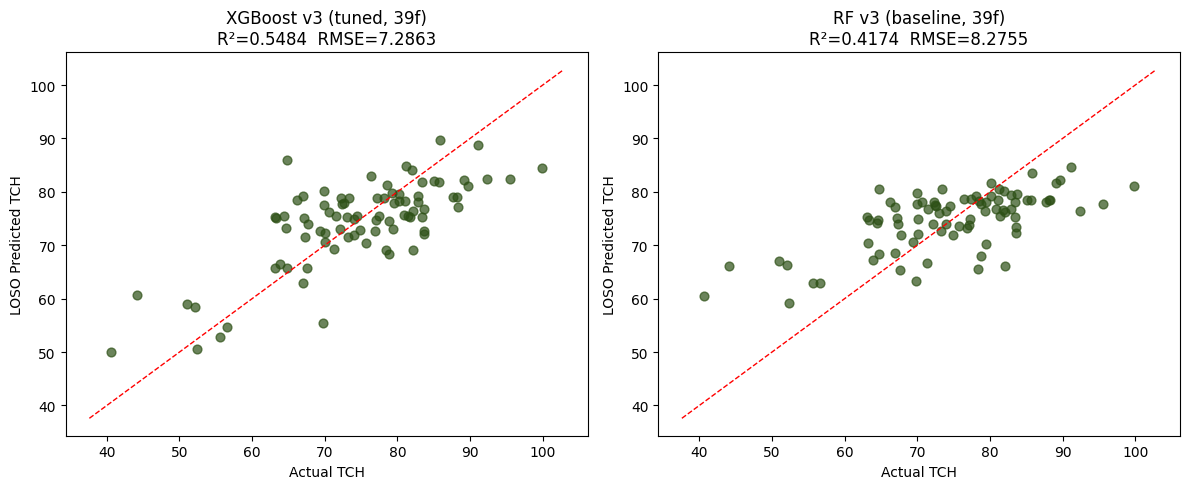

LOSO scatter saved.


In [14]:
print('=' * 68)
print(f'{"Model":<30} {"RMSE":>8} {"MAE":>8} {"R2":>8}')
print('-' * 68)
print(f'{"v1 RF  (Jun-Dec, 31f)":<30} {V1_RF["RMSE"]:>8.4f} {V1_RF["MAE"]:>8.4f} {V1_RF["R2"]:>8.4f}')
print(f'{"v2 RF  (pre-harvest, 35f)":<30} {V2_RF["RMSE"]:>8.4f} {V2_RF["MAE"]:>8.4f} {V2_RF["R2"]:>8.4f}')
print(f'{"v3 RF  (39f, baseline)":<30} {rf_results["loso_rmse"]:>8.4f} {rf_results["loso_mae"]:>8.4f} {rf_results["loso_r2"]:>8.4f}')
print('-' * 68)
print(f'{"v1 XGB (Jun-Dec, 31f)":<30} {V1_XGB["RMSE"]:>8.4f} {V1_XGB["MAE"]:>8.4f} {V1_XGB["R2"]:>8.4f}')
print(f'{"v2 XGB (pre-harvest, 35f)":<30} {V2_XGB["RMSE"]:>8.4f} {V2_XGB["MAE"]:>8.4f} {V2_XGB["R2"]:>8.4f}')
print(f'{"v3 XGB (39f, baseline)":<30} {xgb_results["loso_rmse"]:>8.4f} {xgb_results["loso_mae"]:>8.4f} {xgb_results["loso_r2"]:>8.4f}')
print(f'{"v3 XGB (39f, tuned)":<30} {xgb_tuned_results["loso_rmse"]:>8.4f} {xgb_tuned_results["loso_mae"]:>8.4f} {xgb_tuned_results["loso_r2"]:>8.4f}')
print('=' * 68)

# LOSO scatter
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, res, title in [
    (axes[0], xgb_tuned_results, 'XGBoost v3 (tuned, 39f)'),
    (axes[1], rf_results,        'RF v3 (baseline, 39f)')
]:
    p = res['predictions']
    ax.scatter(p['actual'], p['predicted'], color='#2d5016', alpha=0.7, s=40)
    mn = min(p['actual'].min(), p['predicted'].min()) - 3
    mx = max(p['actual'].max(), p['predicted'].max()) + 3
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1)
    ax.set_xlabel('Actual TCH')
    ax.set_ylabel('LOSO Predicted TCH')
    ax.set_title(f'{title}\nR²={res["loso_r2"]:.4f}  RMSE={res["loso_rmse"]:.4f}')
plt.tight_layout()
plt.savefig(f'{V3_DIR}/loso_scatter_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print('LOSO scatter saved.')

## Cell 13b - Version Comparison Bar Chart

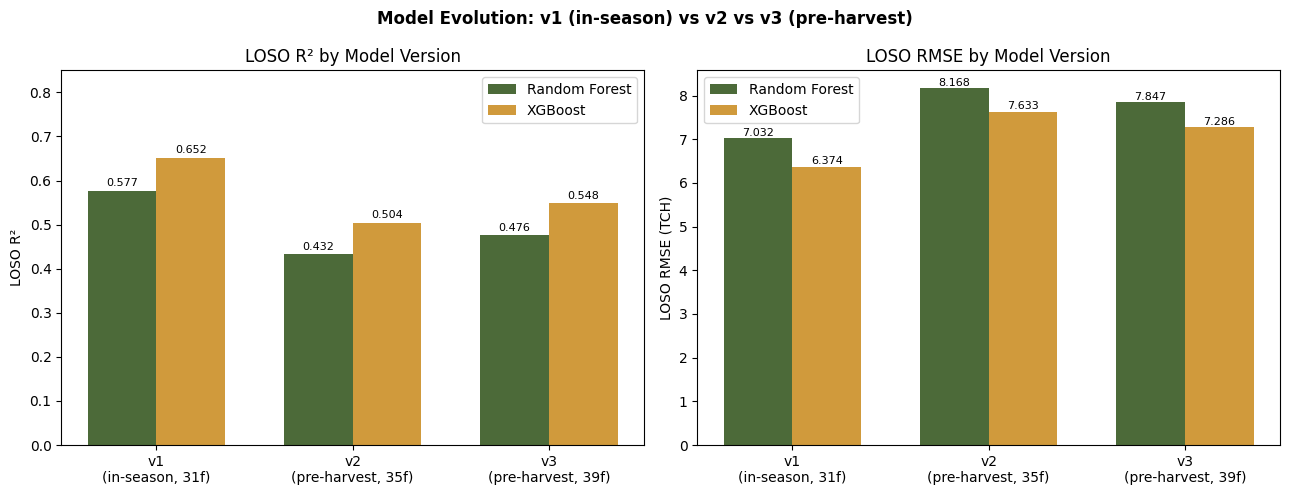

Version comparison chart saved.


In [15]:
# Version comparison bar chart: v1 / v2 / v3 (LOSO metrics)
# Uses rf_tuned_results for v3 RF (from Cell 12b)
labels = ['v1\n(in-season, 31f)', 'v2\n(pre-harvest, 35f)', 'v3\n(pre-harvest, 39f)']

rf_r2    = [V1_RF['R2'],   V2_RF['R2'],   rf_tuned_results['loso_r2']]
xgb_r2   = [V1_XGB['R2'],  V2_XGB['R2'],  xgb_tuned_results['loso_r2']]
rf_rmse  = [V1_RF['RMSE'], V2_RF['RMSE'], rf_tuned_results['loso_rmse']]
xgb_rmse = [V1_XGB['RMSE'],V2_XGB['RMSE'],xgb_tuned_results['loso_rmse']]

x = np.arange(len(labels))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# R2 comparison
axes[0].bar(x - w/2, rf_r2,  w, label='Random Forest', color='#2d5016', alpha=0.85)
axes[0].bar(x + w/2, xgb_r2, w, label='XGBoost',       color='#C8891A', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel('LOSO R²')
axes[0].set_title('LOSO R² by Model Version')
axes[0].legend()
axes[0].set_ylim(0, 0.85)
for i, (rv, xv) in enumerate(zip(rf_r2, xgb_r2)):
    axes[0].text(i - w/2, rv + 0.01, f'{rv:.3f}', ha='center', fontsize=8)
    axes[0].text(i + w/2, xv + 0.01, f'{xv:.3f}', ha='center', fontsize=8)

# RMSE comparison
axes[1].bar(x - w/2, rf_rmse,  w, label='Random Forest', color='#2d5016', alpha=0.85)
axes[1].bar(x + w/2, xgb_rmse, w, label='XGBoost',       color='#C8891A', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel('LOSO RMSE (TCH)')
axes[1].set_title('LOSO RMSE by Model Version')
axes[1].legend()
for i, (rv, xv) in enumerate(zip(rf_rmse, xgb_rmse)):
    axes[1].text(i - w/2, rv + 0.05, f'{rv:.3f}', ha='center', fontsize=8)
    axes[1].text(i + w/2, xv + 0.05, f'{xv:.3f}', ha='center', fontsize=8)

plt.suptitle('Model Evolution: v1 (in-season) vs v2 vs v3 (pre-harvest)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{V3_DIR}/version_comparison_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Version comparison chart saved.')


## Cell 14 - Feature Importance (tuned XGB + RF, full dataset)

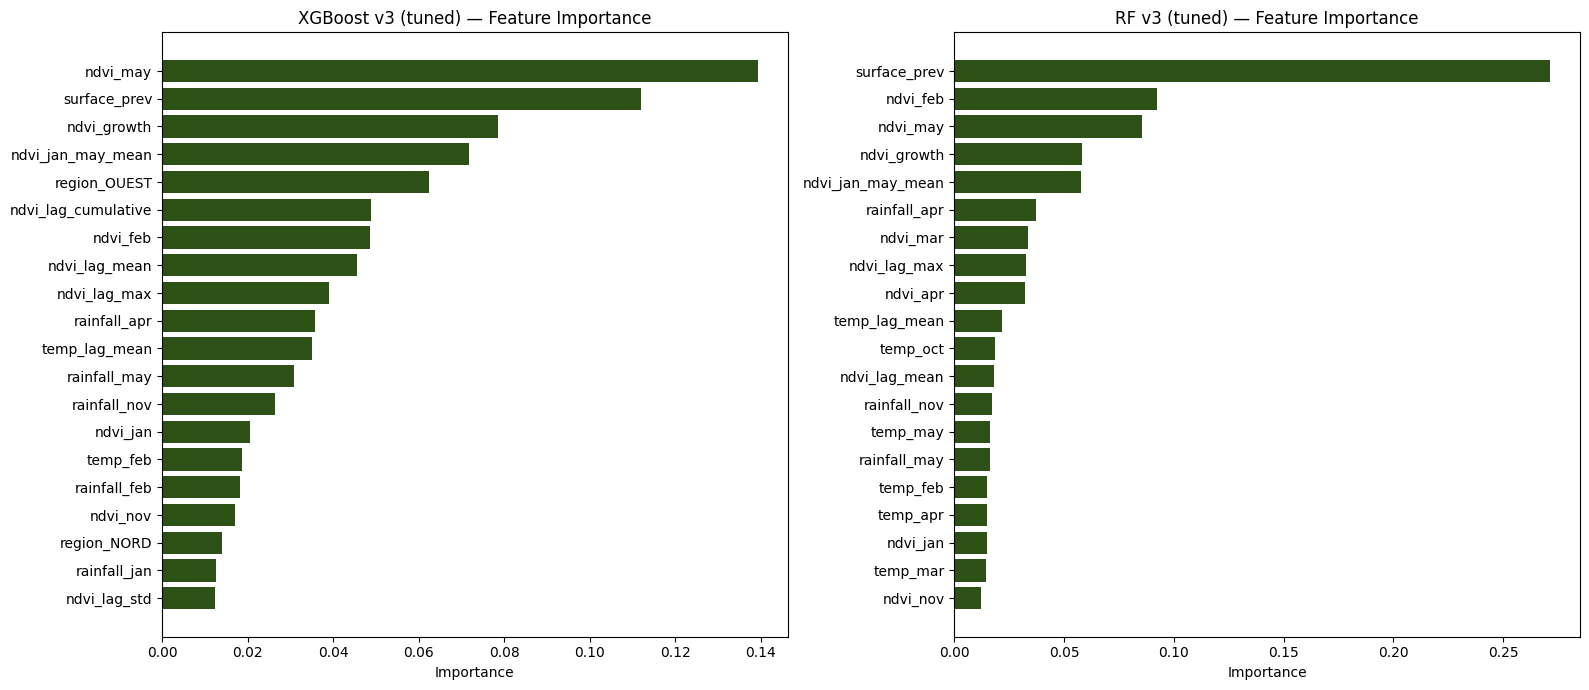

Top 15 features (XGBoost v3 tuned):
            feature  importance
           ndvi_may    0.139401
       surface_prev    0.112104
        ndvi_growth    0.078497
  ndvi_jan_may_mean    0.071857
       region_OUEST    0.062372
ndvi_lag_cumulative    0.048758
           ndvi_feb    0.048710
      ndvi_lag_mean    0.045584
       ndvi_lag_max    0.039045
       rainfall_apr    0.035729
      temp_lag_mean    0.035148
       rainfall_may    0.030846
       rainfall_nov    0.026403
           ndvi_jan    0.020670
           temp_feb    0.018673

Top 15 features (RF v3 tuned):
          feature  importance
     surface_prev    0.271537
         ndvi_feb    0.092250
         ndvi_may    0.085634
      ndvi_growth    0.058327
ndvi_jan_may_mean    0.057676
     rainfall_apr    0.037238
         ndvi_mar    0.033677
     ndvi_lag_max    0.032669
         ndvi_apr    0.032159
    temp_lag_mean    0.021579
         temp_oct    0.018643
    ndvi_lag_mean    0.018095
     rainfall_nov    0.017325


In [16]:
final_rf  = RandomForestRegressor(**best_rf_params, random_state=42, n_jobs=-1)
final_xgb = XGBRegressor(**best_xgb_params, random_state=42, verbosity=0)

final_rf.fit(X, y)
final_xgb.fit(X, y)

df_imp_rf  = pd.DataFrame({'feature': FEATURE_COLS, 'importance': final_rf.feature_importances_}).sort_values('importance', ascending=False)
df_imp_xgb = pd.DataFrame({'feature': FEATURE_COLS, 'importance': final_xgb.feature_importances_}).sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, df_imp, title in [
    (axes[0], df_imp_xgb, 'XGBoost v3 (tuned) — Feature Importance'),
    (axes[1], df_imp_rf,  'RF v3 (tuned) — Feature Importance')
]:
    top20 = df_imp.head(20)
    ax.barh(top20['feature'][::-1], top20['importance'][::-1], color='#2d5016')
    ax.set_title(title)
    ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(f'{V3_DIR}/feature_importance_v3.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 15 features (XGBoost v3 tuned):')
print(df_imp_xgb.head(15).to_string(index=False))
print()
print('Top 15 features (RF v3 tuned):')
print(df_imp_rf.head(15).to_string(index=False))
print()
# Check where cyclone and ENSO land
for feat in ['cyclone_max_wind', 'enso_oni_djf', 'ndvi_growth', 'ndvi_jan_may_mean']:
    row = df_imp_xgb[df_imp_xgb['feature'] == feat]
    if len(row):
        rank = df_imp_xgb.index.get_loc(row.index[0]) + 1
        print(f'  {feat:<22}: importance={row["importance"].values[0]:.4f}  rank={rank}/39')

## Cell 15 - SHAP Analysis (XGBoost v3 tuned)

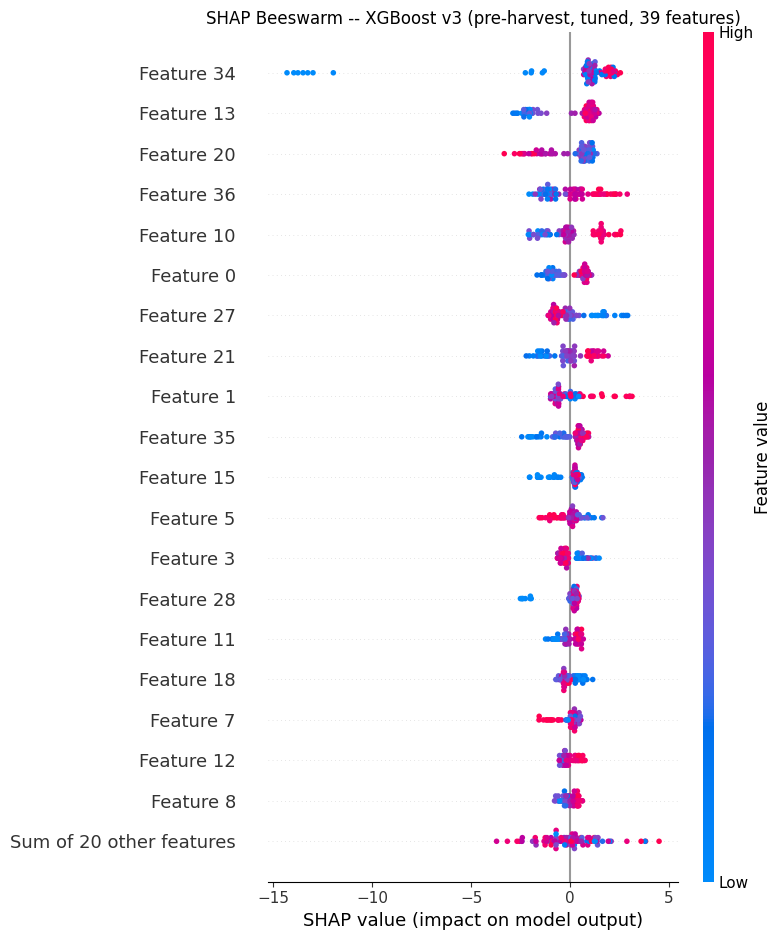

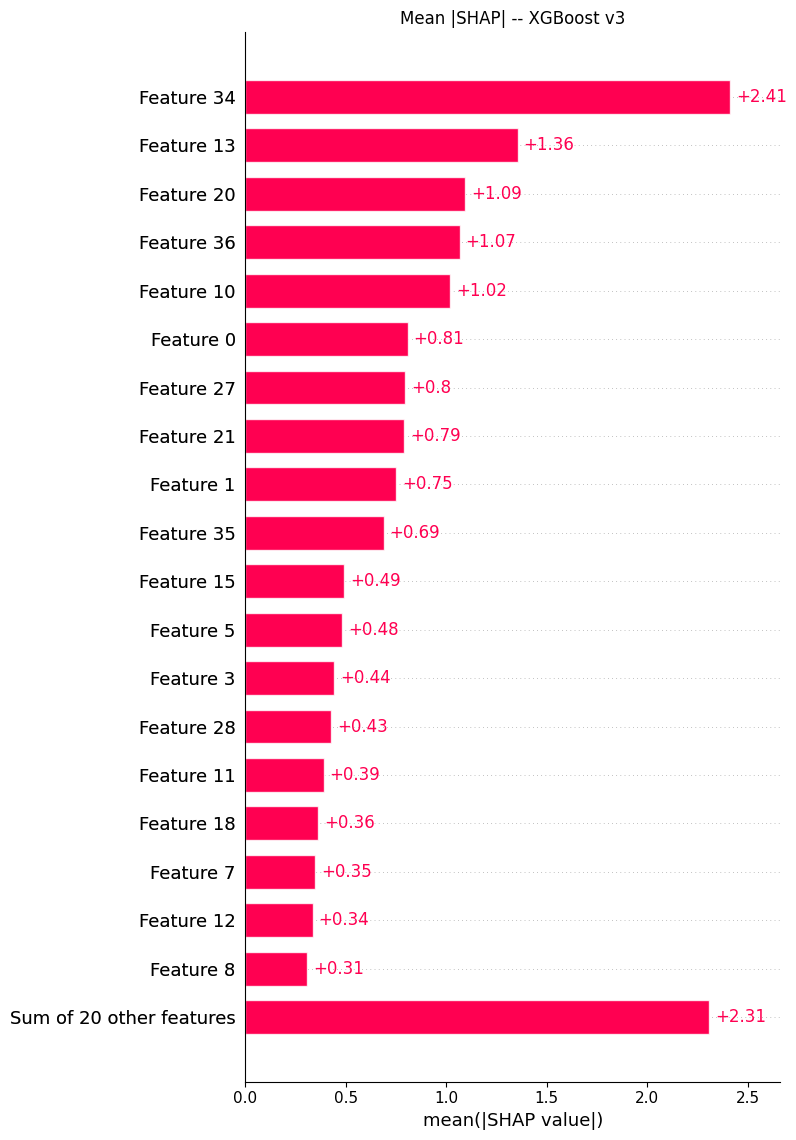

SHAP plots saved.


In [17]:
explainer   = shap.Explainer(final_xgb, X)
shap_values = explainer(X)

plt.figure(figsize=(10, 9))
shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.title('SHAP Beeswarm -- XGBoost v3 (pre-harvest, tuned, 39 features)')
plt.tight_layout()
plt.savefig(f'{V3_DIR}/shap_beeswarm_v3.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 7))
shap.plots.bar(shap_values, max_display=20, show=False)
plt.title('Mean |SHAP| -- XGBoost v3')
plt.tight_layout()
plt.savefig(f'{V3_DIR}/shap_bar_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP plots saved.')

## Cell 15b - LOSO Fold-by-Fold Performance

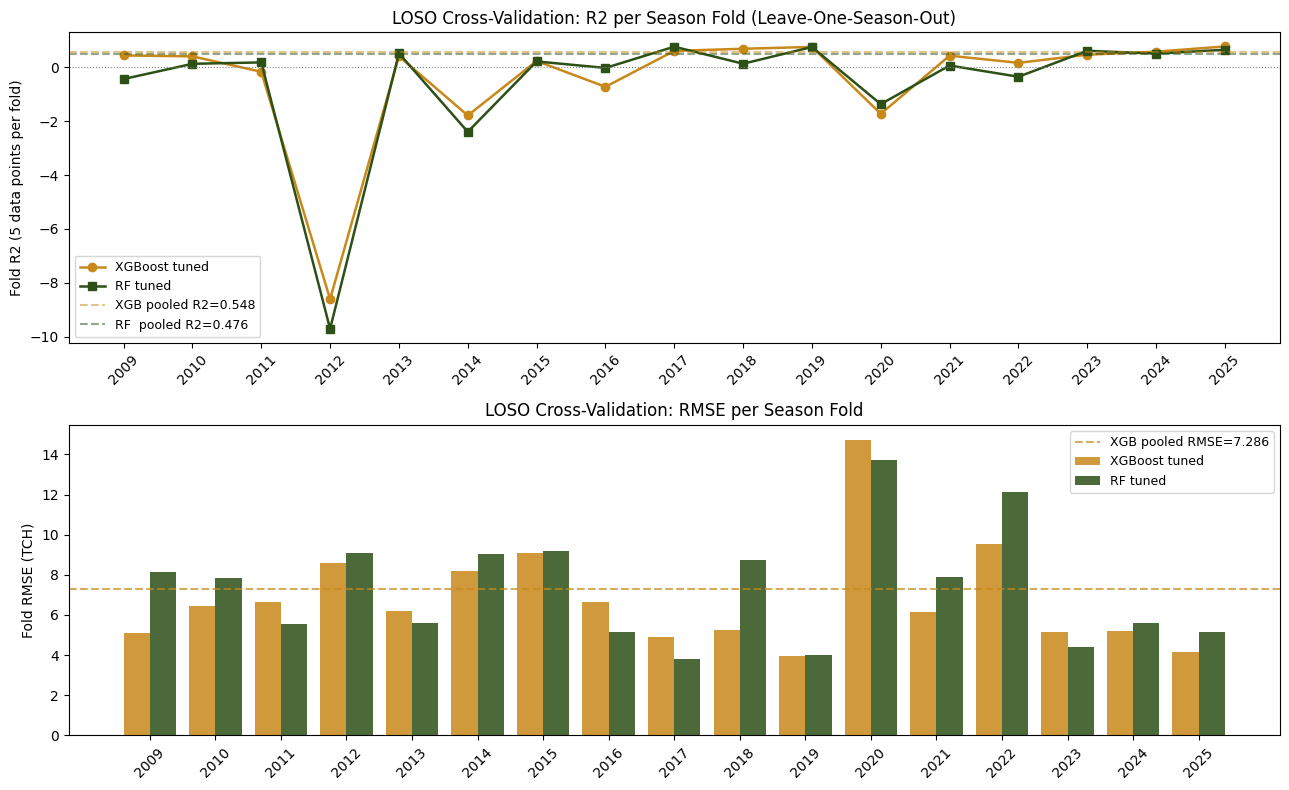

LOSO fold performance chart saved.


In [18]:
# Per-season fold R2 and RMSE for tuned XGB and tuned RF
seasons_loso  = sorted(df['season'].unique())
xgb_fold_r2   = xgb_tuned_results['fold_r2']
xgb_fold_rmse = xgb_tuned_results['fold_rmse']
rf_fold_r2    = rf_tuned_results['fold_r2']
rf_fold_rmse  = rf_tuned_results['fold_rmse']

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# R2 per fold
axes[0].plot(seasons_loso, xgb_fold_r2, 'o-', color='#C8891A', label='XGBoost tuned', linewidth=1.8)
axes[0].plot(seasons_loso, rf_fold_r2,  's-', color='#2d5016', label='RF tuned',       linewidth=1.8)
axes[0].axhline(xgb_tuned_results['loso_r2'],
                color='#C8891A', linestyle='--', alpha=0.5,
                label=f'XGB pooled R2={xgb_tuned_results["loso_r2"]:.3f}')
axes[0].axhline(rf_tuned_results['loso_r2'],
                color='#2d5016', linestyle='--', alpha=0.5,
                label=f'RF  pooled R2={rf_tuned_results["loso_r2"]:.3f}')
axes[0].axhline(0, color='grey', linewidth=0.8, linestyle=':')
axes[0].set_ylabel('Fold R2 (5 data points per fold)')
axes[0].set_title('LOSO Cross-Validation: R2 per Season Fold (Leave-One-Season-Out)')
axes[0].legend(fontsize=9)
axes[0].set_xticks(seasons_loso)
axes[0].tick_params(axis='x', rotation=45)

# RMSE per fold
s = np.array(seasons_loso)
axes[1].bar(s - 0.2, xgb_fold_rmse, 0.4, label='XGBoost tuned', color='#C8891A', alpha=0.85)
axes[1].bar(s + 0.2, rf_fold_rmse,  0.4, label='RF tuned',       color='#2d5016', alpha=0.85)
axes[1].axhline(xgb_tuned_results['loso_rmse'],
                color='#C8891A', linestyle='--', alpha=0.7,
                label=f'XGB pooled RMSE={xgb_tuned_results["loso_rmse"]:.3f}')
axes[1].set_ylabel('Fold RMSE (TCH)')
axes[1].set_title('LOSO Cross-Validation: RMSE per Season Fold')
axes[1].legend(fontsize=9)
axes[1].set_xticks(s)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{V3_DIR}/loso_fold_performance_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print('LOSO fold performance chart saved.')


## Cell 16 - 2025 Holdout Evaluation

Train on 2009-2024 (80 rows), evaluate on 2025 (5 rows).
These are the final deployed models.

Train: 80 rows (2009-2024)
Test:  5 rows (2025 holdout)

=== 2025 Holdout Results ===
Model                            RMSE      MAE       R2
-------------------------------------------------------
v2 RF  (35f)                   5.7991   5.4264   0.5514
v3 RF  (39f, tuned)            5.1282   4.4954   0.6492
-------------------------------------------------------
v2 XGB (35f)                   4.9161   4.2539   0.6777
v3 XGB (39f, tuned)            4.1375   3.7593   0.7717

=== 2025 Predictions by Region ===
Region     Actual      v3 RF     v3 XGB
----------------------------------------
CENTRE       55.6       57.1       52.8
EST          71.5       76.3       75.5
NORD         74.0       76.1       75.0
OUEST        73.4       81.6       78.8
SUD          82.1       76.2       76.5


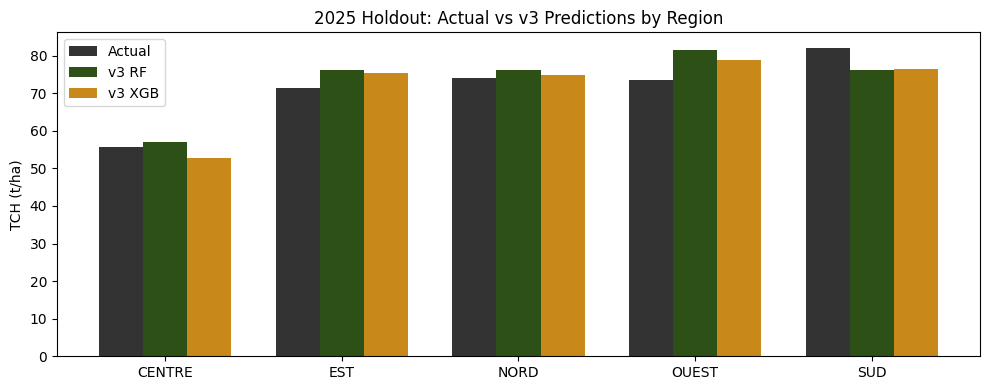

Holdout bar chart saved.


In [19]:
train_mask = df['season'] <= 2024
test_mask  = df['season'] == 2025

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]
regions_2025     = df.loc[test_mask, 'region'].values

print(f'Train: {X_train.shape[0]} rows (2009-2024)')
print(f'Test:  {X_test.shape[0]} rows (2025 holdout)\n')

hold_rf  = RandomForestRegressor(**best_rf_params, random_state=42, n_jobs=-1)
hold_xgb = XGBRegressor(**best_xgb_params, random_state=42, verbosity=0)

hold_rf.fit(X_train, y_train)
hold_xgb.fit(X_train, y_train)

rf_pred  = hold_rf.predict(X_test)
xgb_pred = hold_xgb.predict(X_test)

V2_HOLD_RF  = {'RMSE': 5.7991, 'MAE': 5.4264, 'R2': 0.5514}
V2_HOLD_XGB = {'RMSE': 4.9161, 'MAE': 4.2539, 'R2': 0.6777}

print('=== 2025 Holdout Results ===')
print(f'{"Model":<28} {"RMSE":>8} {"MAE":>8} {"R2":>8}')
print('-' * 55)
print(f'{"v2 RF  (35f)":<28} {V2_HOLD_RF["RMSE"]:>8.4f} {V2_HOLD_RF["MAE"]:>8.4f} {V2_HOLD_RF["R2"]:>8.4f}')
print(f'{"v3 RF  (39f, tuned)":<28} {np.sqrt(mean_squared_error(y_test,rf_pred)):>8.4f} {mean_absolute_error(y_test,rf_pred):>8.4f} {r2_score(y_test,rf_pred):>8.4f}')
print('-' * 55)
print(f'{"v2 XGB (35f)":<28} {V2_HOLD_XGB["RMSE"]:>8.4f} {V2_HOLD_XGB["MAE"]:>8.4f} {V2_HOLD_XGB["R2"]:>8.4f}')
print(f'{"v3 XGB (39f, tuned)":<28} {np.sqrt(mean_squared_error(y_test,xgb_pred)):>8.4f} {mean_absolute_error(y_test,xgb_pred):>8.4f} {r2_score(y_test,xgb_pred):>8.4f}')
print()

print('=== 2025 Predictions by Region ===')
print(f'{"Region":<8} {"Actual":>8} {"v3 RF":>10} {"v3 XGB":>10}')
print('-' * 40)
for reg, act, rfp, xgbp in zip(regions_2025, y_test, rf_pred, xgb_pred):
    print(f'{reg:<8} {act:>8.1f} {rfp:>10.1f} {xgbp:>10.1f}')

x_pos = np.arange(len(regions_2025))
w = 0.25
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x_pos - w,   y_test,   w, label='Actual', color='#333333')
ax.bar(x_pos,       rf_pred,  w, label='v3 RF',  color='#2d5016')
ax.bar(x_pos + w,   xgb_pred, w, label='v3 XGB', color='#C8891A')
ax.set_xticks(x_pos)
ax.set_xticklabels(regions_2025)
ax.set_ylabel('TCH (t/ha)')
ax.set_title('2025 Holdout: Actual vs v3 Predictions by Region')
ax.legend()
plt.tight_layout()
plt.savefig(f'{V3_DIR}/holdout_2025_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Holdout bar chart saved.')

## Cell 16b - Residual Analysis

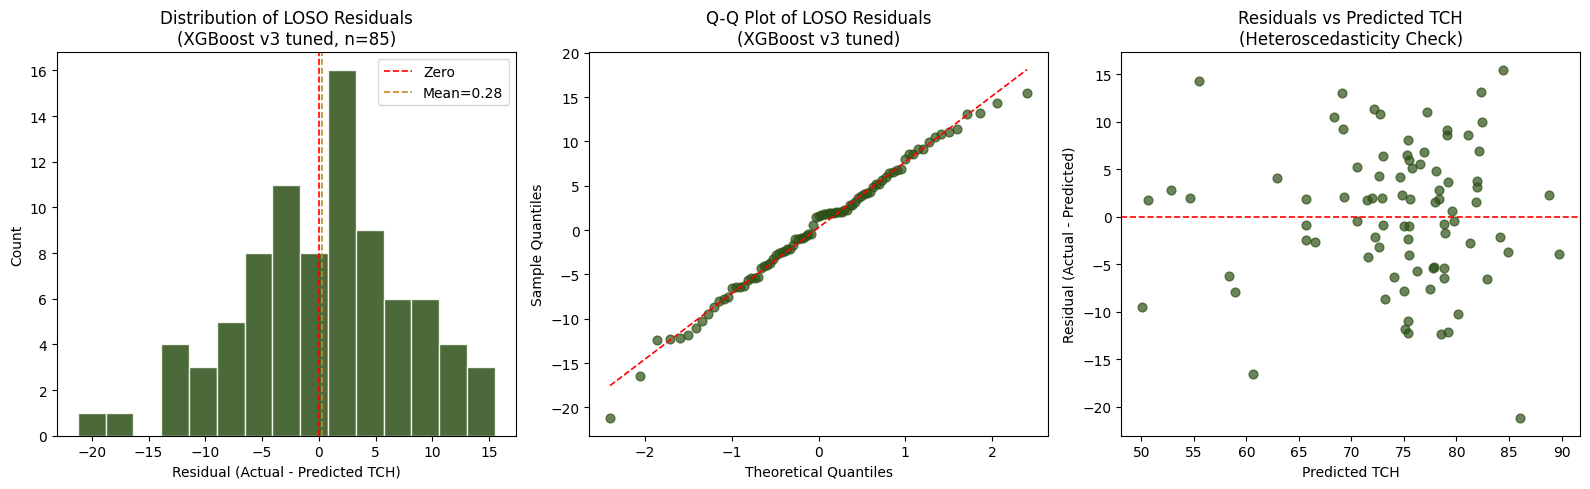

Residual analysis saved.


In [20]:
from scipy import stats as scipy_stats

# LOSO residuals for XGBoost tuned
preds_xgb = xgb_tuned_results['predictions'].copy()
preds_xgb['residual'] = preds_xgb['actual'] - preds_xgb['predicted']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Residual histogram
axes[0].hist(preds_xgb['residual'], bins=15, color='#2d5016', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.2, label='Zero')
axes[0].axvline(preds_xgb['residual'].mean(), color='#C8891A', linestyle='--', linewidth=1.2,
                label=f'Mean={preds_xgb["residual"].mean():.2f}')
axes[0].set_xlabel('Residual (Actual - Predicted TCH)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of LOSO Residuals\n(XGBoost v3 tuned, n=85)')
axes[0].legend()

# 2. Q-Q plot
(osm, osr), (slope, intercept, r) = scipy_stats.probplot(preds_xgb['residual'], dist='norm')
axes[1].scatter(osm, osr, color='#2d5016', alpha=0.7, s=40)
fit_line = slope * np.array([osm.min(), osm.max()]) + intercept
axes[1].plot([osm.min(), osm.max()], fit_line, 'r--', linewidth=1.2)
axes[1].set_xlabel('Theoretical Quantiles')
axes[1].set_ylabel('Sample Quantiles')
axes[1].set_title('Q-Q Plot of LOSO Residuals\n(XGBoost v3 tuned)')

# 3. Residuals vs Predicted (heteroscedasticity check)
axes[2].scatter(preds_xgb['predicted'], preds_xgb['residual'], color='#2d5016', alpha=0.7, s=40)
axes[2].axhline(0, color='red', linestyle='--', linewidth=1.2)
axes[2].set_xlabel('Predicted TCH')
axes[2].set_ylabel('Residual (Actual - Predicted)')
axes[2].set_title('Residuals vs Predicted TCH\n(Heteroscedasticity Check)')

plt.tight_layout()
plt.savefig(f'{V3_DIR}/residual_analysis_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Residual analysis saved.')


## Cell 16c - Statistical Tests

In [21]:
from scipy.stats import shapiro, ttest_1samp, wilcoxon

def run_stat_tests(results_dict, label, n_label='85'):
    preds = results_dict['predictions'].copy()
    residuals = preds['actual'].values - preds['predicted'].values
    n = len(residuals)

    print(f'STATISTICAL TESTS -- {label}  (LOSO residuals, n={n})')
    print('=' * 62)

    # 1. Shapiro-Wilk normality test
    sw_stat, sw_p = shapiro(residuals)
    print(f'1. Shapiro-Wilk (normality of residuals):')
    print(f'   W={sw_stat:.4f},  p={sw_p:.4f}')
    verdict = 'approximately normal (p>0.05)' if sw_p > 0.05 else 'non-normal (p<=0.05)'
    print(f'   Verdict: residuals are {verdict}')

    # 2. One-sample t-test: H0 = no systematic bias (mean residual = 0)
    t_stat, t_p = ttest_1samp(residuals, 0)
    print(f'\n2. One-sample t-test (H0: mean residual = 0, no systematic bias):')
    print(f'   t={t_stat:.4f},  p={t_p:.4f},  mean residual={residuals.mean():.4f} TCH')
    verdict = 'no significant bias (p>0.05)' if t_p > 0.05 else 'significant bias detected (p<=0.05)'
    print(f'   Verdict: {verdict}')

    # 3. Wilcoxon signed-rank (non-parametric, H0: median residual = 0)
    try:
        w_stat, w_p = wilcoxon(residuals)
        print(f'\n3. Wilcoxon signed-rank (H0: median residual = 0):')
        print(f'   W={w_stat:.1f},  p={w_p:.4f}')
        verdict = 'no significant median bias (p>0.05)' if w_p > 0.05 else 'significant median bias (p<=0.05)'
        print(f'   Verdict: {verdict}')
    except Exception as e:
        print(f'\n3. Wilcoxon skipped: {e}')

    # 4. MAPE
    mape = np.mean(np.abs(residuals / preds['actual'].values)) * 100
    print(f'\n4. Mean Absolute Percentage Error (MAPE): {mape:.2f}%')

    # 5. Prediction tolerance
    within_5  = np.mean(np.abs(residuals) <= 5)  * 100
    within_10 = np.mean(np.abs(residuals) <= 10) * 100
    print(f'\n5. Prediction tolerance:')
    print(f'   Within +/-5  TCH: {within_5:.1f}% of predictions')
    print(f'   Within +/-10 TCH: {within_10:.1f}% of predictions')
    print()

run_stat_tests(xgb_tuned_results, 'XGBoost v3 (tuned)')
run_stat_tests(rf_tuned_results,  'RF v3 (tuned)')


STATISTICAL TESTS -- XGBoost v3 (tuned)  (LOSO residuals, n=85)
1. Shapiro-Wilk (normality of residuals):
   W=0.9901,  p=0.7692
   Verdict: residuals are approximately normal (p>0.05)

2. One-sample t-test (H0: mean residual = 0, no systematic bias):
   t=0.3534,  p=0.7247,  mean residual=0.2807 TCH
   Verdict: no significant bias (p>0.05)

3. Wilcoxon signed-rank (H0: median residual = 0):
   W=1706.0,  p=0.5945
   Verdict: no significant median bias (p>0.05)

4. Mean Absolute Percentage Error (MAPE): 8.18%

5. Prediction tolerance:
   Within +/-5  TCH: 49.4% of predictions
   Within +/-10 TCH: 81.2% of predictions

STATISTICAL TESTS -- RF v3 (tuned)  (LOSO residuals, n=85)
1. Shapiro-Wilk (normality of residuals):
   W=0.9871,  p=0.5617
   Verdict: residuals are approximately normal (p>0.05)

2. One-sample t-test (H0: mean residual = 0, no systematic bias):
   t=-0.2549,  p=0.7994,  mean residual=-0.2182 TCH
   Verdict: no significant bias (p>0.05)

3. Wilcoxon signed-rank (H0: medi

## Cell 16d - Regional Performance Breakdown (LOSO)

Regional LOSO Performance Breakdown
Region       XGB RMSE   XGB MAE   XGB R2    RF RMSE   RF MAE   RF R2
--------------------------------------------------------------------
NORD            4.583     3.558    0.234      4.715    3.750   0.189
SUD             6.568     5.702   -0.057      6.596    5.554  -0.066
EST             6.315     5.346    0.153      6.513    5.246   0.099
OUEST          10.182     8.911    0.180     10.879    9.859   0.064
CENTRE          7.600     5.795    0.547      9.023    6.577   0.362


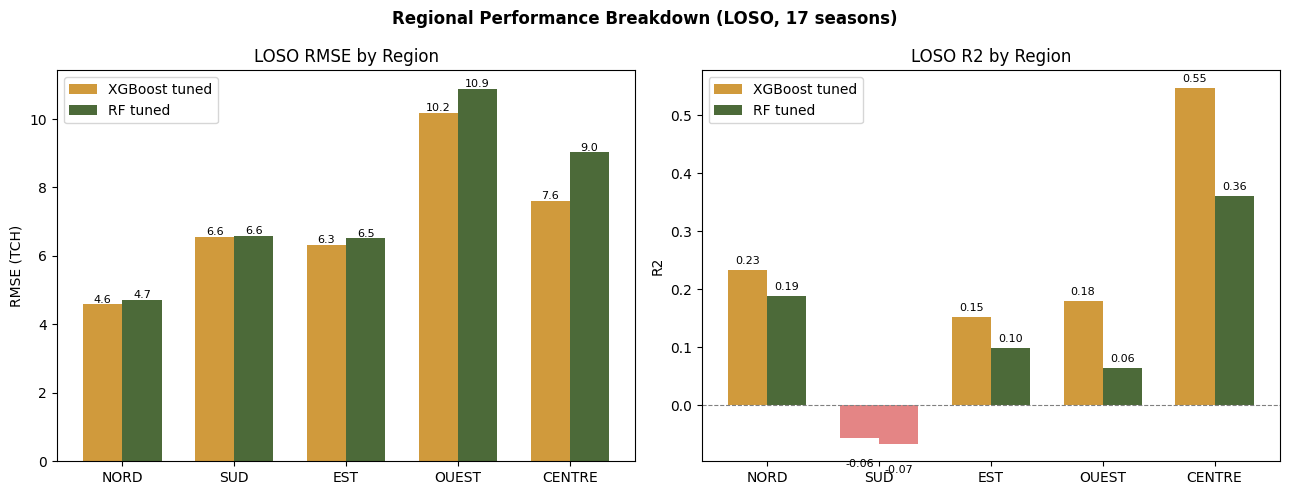

Regional performance chart saved.


In [22]:
# Recover region for each LOSO prediction by merging on (season, actual TCH)
preds_xgb = xgb_tuned_results['predictions'].copy()
preds_rf   = rf_tuned_results['predictions'].copy()

df_keys = df[['season', 'region', 'tch']].copy()
df_keys['actual_r'] = df_keys['tch'].round(3)

def add_region(preds_df):
    p = preds_df.copy()
    p['actual_r'] = p['actual'].round(3)
    merged = p.merge(df_keys[['season', 'actual_r', 'region']],
                     on=['season', 'actual_r'], how='left')
    missing = merged['region'].isnull().sum()
    if missing > 0:
        print(f'  Warning: {missing} rows could not be matched to a region')
    return merged

preds_xgb = add_region(preds_xgb)
preds_rf   = add_region(preds_rf)

REGIONS = ['NORD', 'SUD', 'EST', 'OUEST', 'CENTRE']

region_data_xgb = {}
region_data_rf  = {}

print('Regional LOSO Performance Breakdown')
print('=' * 68)
print(f'{"Region":<10} {"XGB RMSE":>10} {"XGB MAE":>9} {"XGB R2":>8}  {"RF RMSE":>9} {"RF MAE":>8} {"RF R2":>7}')
print('-' * 68)

for reg in REGIONS:
    sx = preds_xgb[preds_xgb['region'] == reg]
    sr = preds_rf[preds_rf['region'] == reg]
    if len(sx) < 2:
        continue
    x_rmse = np.sqrt(mean_squared_error(sx['actual'], sx['predicted']))
    x_mae  = mean_absolute_error(sx['actual'], sx['predicted'])
    x_r2   = r2_score(sx['actual'], sx['predicted'])
    r_rmse = np.sqrt(mean_squared_error(sr['actual'], sr['predicted']))
    r_mae  = mean_absolute_error(sr['actual'], sr['predicted'])
    r_r2   = r2_score(sr['actual'], sr['predicted'])
    region_data_xgb[reg] = {'RMSE': x_rmse, 'MAE': x_mae, 'R2': x_r2}
    region_data_rf[reg]  = {'RMSE': r_rmse, 'MAE': r_mae, 'R2': r_r2}
    print(f'{reg:<10} {x_rmse:>10.3f} {x_mae:>9.3f} {x_r2:>8.3f}  {r_rmse:>9.3f} {r_mae:>8.3f} {r_r2:>7.3f}')

print('=' * 68)

# Visualization
regions_plot = [r for r in REGIONS if r in region_data_xgb]
xgb_rmse_r = [region_data_xgb[r]['RMSE'] for r in regions_plot]
rf_rmse_r  = [region_data_rf[r]['RMSE']  for r in regions_plot]
xgb_r2_r   = [region_data_xgb[r]['R2']   for r in regions_plot]
rf_r2_r    = [region_data_rf[r]['R2']    for r in regions_plot]

x = np.arange(len(regions_plot))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(x - w/2, xgb_rmse_r, w, label='XGBoost tuned', color='#C8891A', alpha=0.85)
axes[0].bar(x + w/2, rf_rmse_r,  w, label='RF tuned',       color='#2d5016', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(regions_plot)
axes[0].set_ylabel('RMSE (TCH)')
axes[0].set_title('LOSO RMSE by Region')
axes[0].legend()
for i, (xv, rv) in enumerate(zip(xgb_rmse_r, rf_rmse_r)):
    axes[0].text(i - w/2, xv + 0.05, f'{xv:.1f}', ha='center', fontsize=8)
    axes[0].text(i + w/2, rv + 0.05, f'{rv:.1f}', ha='center', fontsize=8)

clr_xgb = ['#C8891A' if v >= 0 else '#e07070' for v in xgb_r2_r]
clr_rf  = ['#2d5016' if v >= 0 else '#e07070' for v in rf_r2_r]
axes[1].bar(x - w/2, xgb_r2_r, w, label='XGBoost tuned', color=clr_xgb, alpha=0.85)
axes[1].bar(x + w/2, rf_r2_r,  w, label='RF tuned',       color=clr_rf,  alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(regions_plot)
axes[1].axhline(0, color='grey', linewidth=0.8, linestyle='--')
axes[1].set_ylabel('R2')
axes[1].set_title('LOSO R2 by Region')
axes[1].legend()
for i, (xv, rv) in enumerate(zip(xgb_r2_r, rf_r2_r)):
    yoff = 0.01 if xv >= 0 else -0.05
    axes[1].text(i - w/2, xv + yoff, f'{xv:.2f}', ha='center', fontsize=8)
    yoff = 0.01 if rv >= 0 else -0.05
    axes[1].text(i + w/2, rv + yoff, f'{rv:.2f}', ha='center', fontsize=8)

plt.suptitle('Regional Performance Breakdown (LOSO, 17 seasons)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{V3_DIR}/regional_performance_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Regional performance chart saved.')


## Cell 17 - Save Models & Artefacts

In [23]:
joblib.dump(hold_rf, RF_MODEL_OUT)
print(f'RF  model saved -> {RF_MODEL_OUT}')

joblib.dump(hold_xgb, XGB_MODEL_OUT)
print(f'XGB model saved -> {XGB_MODEL_OUT}')

df_loso_xgb = xgb_tuned_results['predictions'].copy(); df_loso_xgb['model'] = 'xgb_v3_tuned'
df_loso_rf  = rf_tuned_results['predictions'].copy();  df_loso_rf['model']  = 'rf_v3_tuned'
pd.concat([df_loso_xgb, df_loso_rf]).to_csv(PREDS_OUT, index=False)
print(f'LOSO preds      -> {PREDS_OUT}')

feat_path = f'{V3_DIR}/feature_cols_v3.json'
with open(feat_path, 'w') as fp:
    json.dump(FEATURE_COLS, fp, indent=2)
print(f'Feature list    -> {feat_path}')

params_path = f'{V3_DIR}/best_params_v3.json'
with open(params_path, 'w') as fp:
    json.dump({'xgb': best_xgb_params, 'rf': best_rf_params}, fp, indent=2, default=str)
print(f'Best XGB params -> {params_path}')

hold_rf_rmse  = float(np.sqrt(mean_squared_error(y_test, rf_pred)))
hold_rf_r2    = float(r2_score(y_test, rf_pred))
hold_xgb_rmse = float(np.sqrt(mean_squared_error(y_test, xgb_pred)))
hold_xgb_r2   = float(r2_score(y_test, xgb_pred))
print(f'\n{"="*55}')
print(f'Final Summary -- v3 revised (39 features, both models tuned)')
print(f'{"="*55}')
print(f'Dataset:   85 rows, 2009-2025, 5 regions')
print(f'Features:  {len(FEATURE_COLS)}')
print(f'\nLOSO XGB (tuned):  RMSE={xgb_tuned_results["loso_rmse"]:.4f}  MAE={xgb_tuned_results["loso_mae"]:.4f}  R2={xgb_tuned_results["loso_r2"]:.4f}')
print(f'LOSO RF  (tuned):  RMSE={rf_tuned_results["loso_rmse"]:.4f}  MAE={rf_tuned_results["loso_mae"]:.4f}  R2={rf_tuned_results["loso_r2"]:.4f}')
print(f'\n2025 Holdout RF:   RMSE={hold_rf_rmse:.4f}  R2={hold_rf_r2:.4f}')
print(f'2025 Holdout XGB:  RMSE={hold_xgb_rmse:.4f}  R2={hold_xgb_r2:.4f}')
print(f'Models saved to:   {V3_DIR}')

RF  model saved -> /content/drive/MyDrive/CST3990 - Final Year Project/model_v3/rf_model_v3.joblib
XGB model saved -> /content/drive/MyDrive/CST3990 - Final Year Project/model_v3/xgb_model_v3.joblib
LOSO preds      -> /content/drive/MyDrive/CST3990 - Final Year Project/model_v3/loso_predictions_v3.csv
Feature list    -> /content/drive/MyDrive/CST3990 - Final Year Project/model_v3/feature_cols_v3.json
Best XGB params -> /content/drive/MyDrive/CST3990 - Final Year Project/model_v3/best_params_v3.json

Final Summary -- v3 revised (39 features, both models tuned)
Dataset:   85 rows, 2009-2025, 5 regions
Features:  39

LOSO XGB (tuned):  RMSE=7.2863  MAE=5.8623  R2=0.5484
LOSO RF  (tuned):  RMSE=7.8474  MAE=6.1972  R2=0.4762

2025 Holdout RF:   RMSE=5.1282  R2=0.6492
2025 Holdout XGB:  RMSE=4.1375  R2=0.7717
Models saved to:   /content/drive/MyDrive/CST3990 - Final Year Project/model_v3
